# 🏥 Medical Appointment No-Show Analysis Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv("appointment_noshow.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [ ]:
df[df.isnull().any(axis=1)]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show


This code in upper block is useful remember this umer

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df["Waiting Days"] = ((df['ScheduledDay']-df['AppointmentDay'])).dt.days
df.head(3)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Waiting Days
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0


In [ ]:
waiting_df = df[df['Waiting Days'] >= 0].copy()
#waiting_df['Waiting Days'].describe()
waiting_df.groupby('Waiting Days')['No-show'].value_counts(normalize=True)

Waiting Days  No-show
0             No         0.953531
              Yes        0.046469
1             Yes        1.000000
6             Yes        1.000000
Name: proportion, dtype: float64

,proportion
No-show,
No,0.798067
Yes,0.201933


<Axes: xlabel='No-show', ylabel='count'>

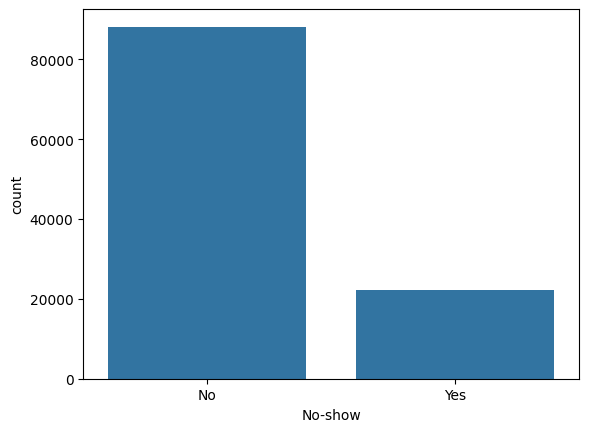

In [ ]:
display(df['No-show'].value_counts(normalize=True))

print()

sns.countplot(data=df,x='No-show')

Gender  No-show
F       No         0.796854
        Yes        0.203146
M       No         0.800321
        Yes        0.199679
Name: proportion, dtype: float64

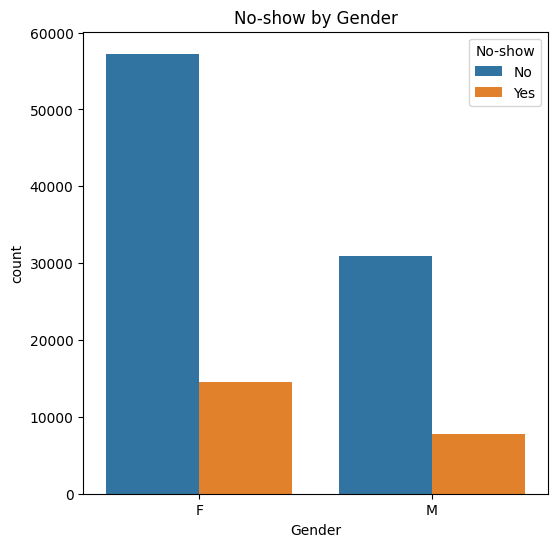

In [ ]:
display(df.groupby('Gender')["No-show"].value_counts(normalize=True))
print()
plt.figure(figsize=(6,6))
sns.countplot(data=df,x='Gender',hue='No-show')
plt.title("No-show by Gender")
plt.show()

In [ ]:
#df['Age'].value_counts()
bins=[0,18,35,60,120]
labels=['child','adult','middle age','senior']
df['Age_group']=pd.cut(df['Age'],bins=bins,labels=labels)

df.head(3)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Waiting Days,Age_group
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,senior
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,middle age
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,senior


/tmp/ipykernel_881/666306825.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('Age_group')['No-show'].value_counts(normalize=True))


Age_group   No-show
child       No         0.774628
            Yes        0.225372
adult       No         0.761652
            Yes        0.238348
middle age  No         0.808983
            Yes        0.191017
senior      No         0.847890
            Yes        0.152110
Name: proportion, dtype: float64

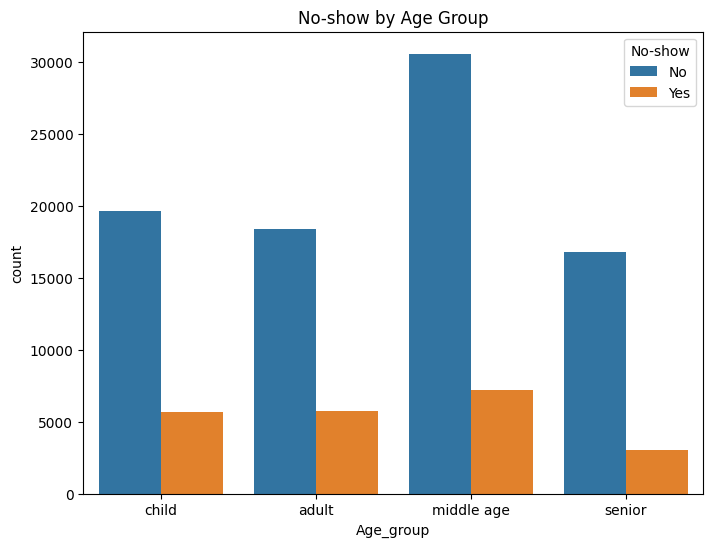

In [ ]:
display(df.groupby('Age_group')['No-show'].value_counts(normalize=True))
print()
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='Age_group',hue='No-show')
plt.title("No-show by Age Group")
plt.show()

SMS_received  No-show
0             No         0.832967
              Yes        0.167033
1             No         0.724255
              Yes        0.275745
Name: proportion, dtype: float64

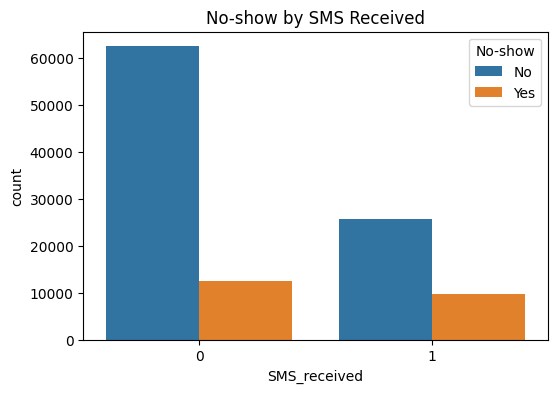

In [ ]:
display(df.groupby('SMS_received')['No-show'].value_counts(normalize=True))
print()
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='SMS_received',hue='No-show')
plt.title("No-show by SMS Received")
plt.show()

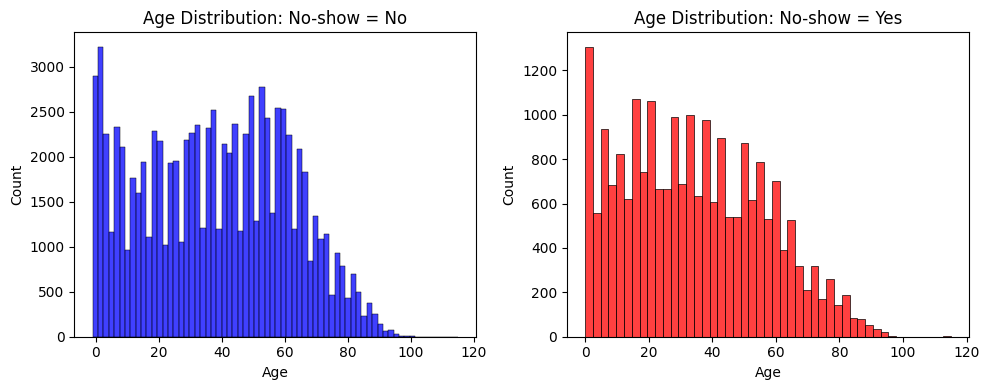

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df[df['No-show']=='No'], x='Age', color='blue')
plt.title("Age Distribution: No-show = No")

plt.subplot(1,2,2)
sns.histplot(data=df[df['No-show']=='Yes'], x='Age', color='red')
plt.title("Age Distribution: No-show = Yes")

plt.tight_layout()
plt.show()

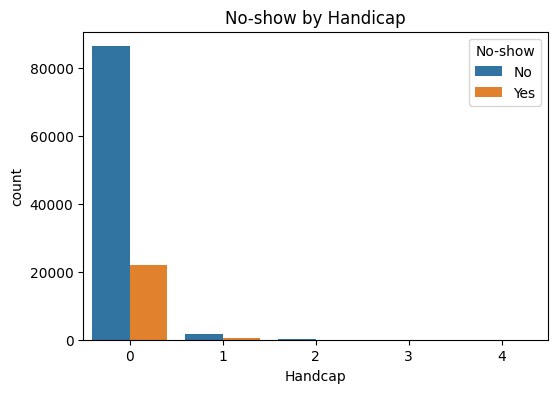

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Handcap',hue='No-show')
plt.title("No-show by Handicap")
plt.show()

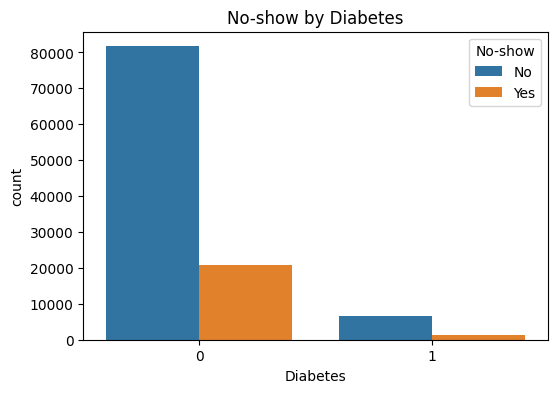

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Diabetes',hue='No-show')
plt.title("No-show by Diabetes")
plt.show()

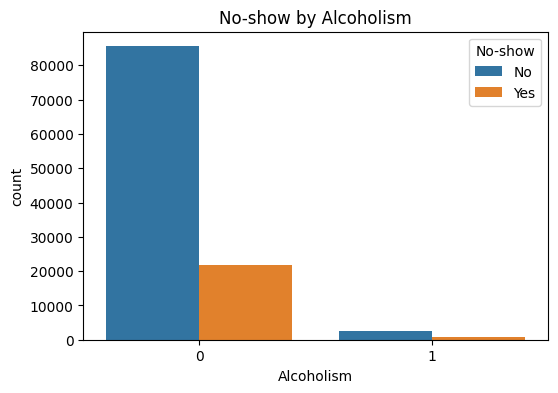

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Alcoholism',hue='No-show')
plt.title("No-show by Alcoholism")
plt.show()

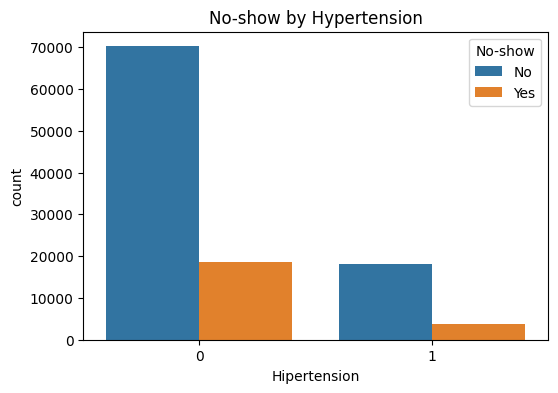

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Hipertension',hue='No-show')
plt.title("No-show by Hypertension")
plt.show()

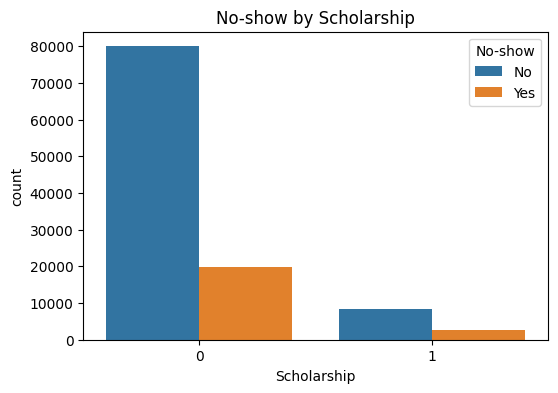

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Scholarship',hue='No-show')
plt.title("No-show by Scholarship")
plt.show()

In [ ]:
df['Neighbourhood'].nunique()

81

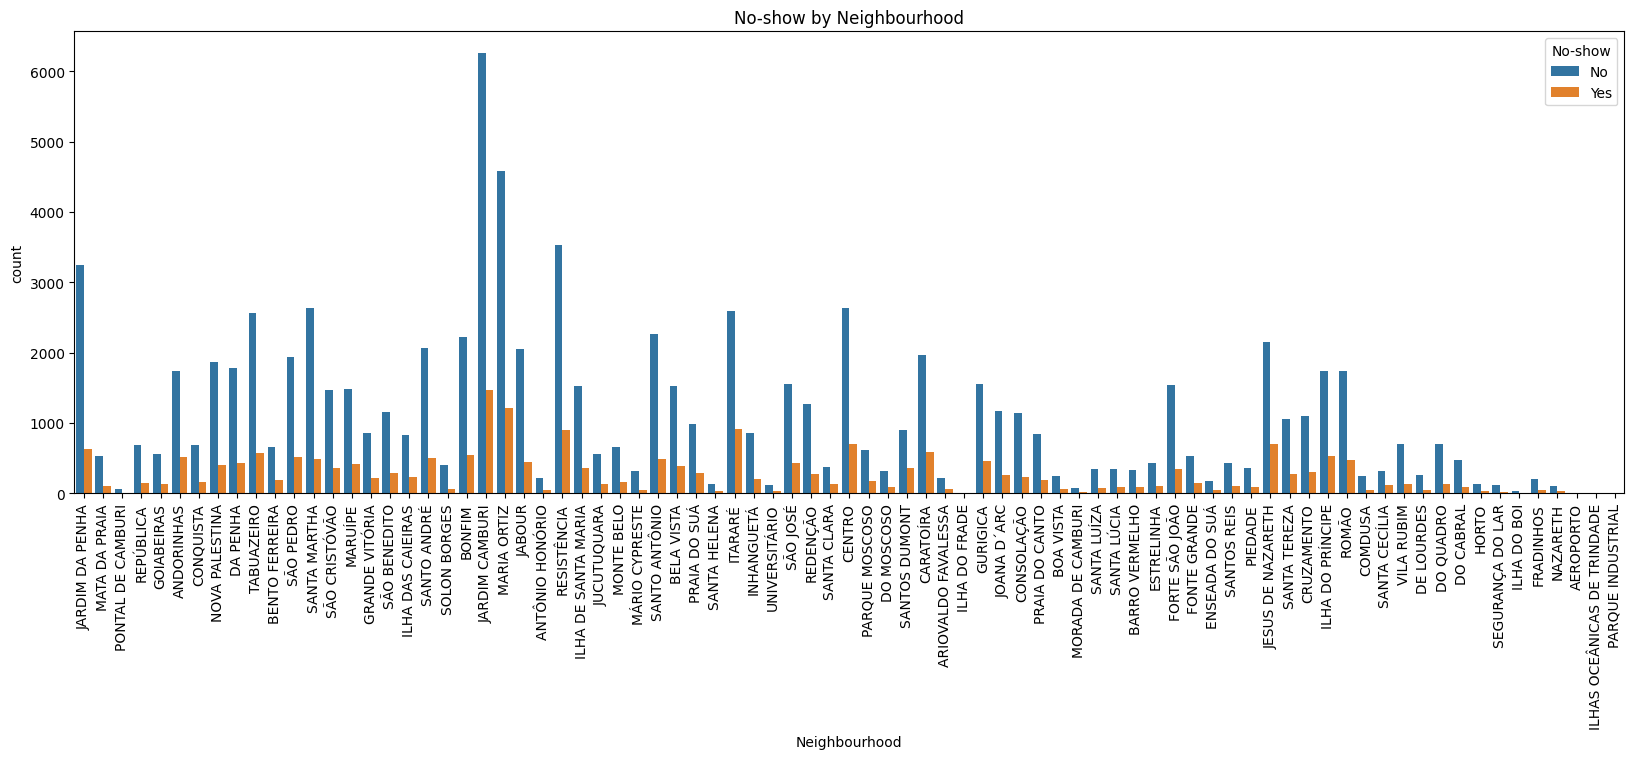

In [ ]:
plt.figure(figsize=(20,6))
sns.countplot(data=df,x='Neighbourhood',hue='No-show')
plt.title("No-show by Neighbourhood")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['Weekday'] = df['AppointmentDay'].dt.day_name()
#df.head(3)
df['Weekday'].nunique()

6

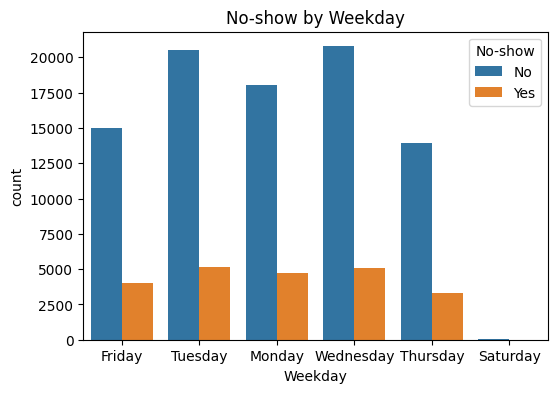

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Weekday',hue='No-show')
plt.title("No-show by Weekday")
plt.show()

# **🎯 Final Conclusion**

**The analysis found that 20.19% of scheduled appointments resulted in no-shows. The data shows clear associations between no-shows and certain factors, particularly age and SMS reminder status. Adults had the highest no-show rate at 23.83%, while seniors had the lowest at 15.21%. Patients who received SMS reminders also showed a higher no-show rate (27.57%) compared with those who did not receive them (16.70%). Gender showed almost no meaningful difference.**

**However, the dataset does not contain the actual reasons why patients missed their appointments. Therefore, the analysis cannot identify a definitive cause of no-shows. It can only identify patterns and factors associated with a higher likelihood of missing an appointment.**

In [ ]:
df.to_csv("appointment_noshow_cleaned.csv",index=False)
